# <font size=6><center>A. Các tác vụ thường dùng với file PDF


1. [Tách 1 File thành từng file lẻ mỗi file/trang](https://colab.research.google.com/drive/1Bkod-KmT3sU7w3JfpjLTGRf_h1lwOH1E#scrollTo=lbYm1bIH3mJs&line=6&uniqifier=1)
2. [Gọp nhiều file trong thư mục thành 1 file ](https://colab.research.google.com/drive/1Bkod-KmT3sU7w3JfpjLTGRf_h1lwOH1E#scrollTo=aGMJHPD5QHG9&line=3&uniqifier=1)
3. [Xoay trang trong PDF](https://colab.research.google.com/drive/1Bkod-KmT3sU7w3JfpjLTGRf_h1lwOH1E#scrollTo=gee7A2z9mi-H&line=23&uniqifier=1)
4. Ngoài ra còn nhiều tính năng khác như: Chuyển đổi kích cỡ file PDF; Trích xuất attachment; hình ảnh, con dấu, chữ ký (ko có nhu cầu nên chưa thử). Có thể xem thêm tại [pypdf documentation](https://pypdf.readthedocs.io/en/latest/index.html) của maintainer hiện tại @Martin Thoma


In [ ]:
# @title <font size="4"> 1/ Tách PDF thành nhiều file 1 file/trang - Upload kiểu thủ công mỗi lần có 1 file - chậm dành cho ai không mở google drive{"vertical-output":true}
!pip install pypdf
from pypdf import PdfReader, PdfWriter
import os,shutil, time
from posix import mkdir
from IPython.display import clear_output
#@markdown <font size="3" color=red><===Click nút play này - Xong đợi hiện nút Choose File hiện dưới dòng này. Click để upload file pdf
uploaded = files.upload()
for filename in uploaded.keys():
    input_file=filename
basename_pdf = str(os.path.basename(input_file)).split('.')[0]

output_path = os.path.join(os.getcwd(), f"{basename_pdf}")
os.mkdir(output_path)
reader = PdfReader(input_file)
num_pages = reader.pages

''' Duyệt qua từng trang và lưu thành file riêng lẻ '''
for page_number in range(len(num_pages)):
    writer = PdfWriter()
    writer.add_page(reader.pages[page_number])
    ''' Đặt trên từng trang theo dạng: Trang_(số trang)_tên file gốc.pdf '''
    output_pdf_path = f"{output_path}/Trang_{page_number + 1}_{basename_pdf}.pdf"
    with open(output_pdf_path, "wb") as output_file:
        writer.write(output_file)
    print(f"Trang {page_number + 1}/{num_pages} đã được lưu tại {output_path}")
    ''' Nén thư mục các file vừa xuất thành 1 file pdf -> download '''
    archive = shutil.make_archive(f"{basename_pdf}", 'zip', output_path)
    files.download(archive)
print("Tách file PDF hoàn tất!")
print(f"Tải file {archive}")
''' Tắt tab - out session file upload tự xoá '''
time.sleep(3)
writer.close()
clear_output()

In [ ]:
#@title 2/Gọp tất cả file pdf trong thư mục thành 1 (có tích hợp google drive) (Như ví dụ ở dưới, màu đỏ là tên thư mục, vàng là thư mục con của thư mục đỏ, màu xanh lá là tên file PDF)
!pip install pypdf
from pypdf import PdfWriter, PdfReader
#@markdown ##Kết nối  Google Drive
from google.colab import drive, files
from IPython.display import clear_output, display, HTML, Image, IFrame
drive.mount('/content/drive')
writer = PdfWriter()
#@markdown *Tên thư mục bao gồm đường dẫn có dạng: /content/drive/MyDrive/<font color=red>Tên Thư Mục/<font color=yellow>Tên thư muc-con/<font color=green>tên file.pdf*
filelist = []
pdf_folder = "" #@param {type:"string", "placeholder": "Tên thư mục các file PDF"}
for file in os.listdir(pdf_folder):
    if file.endswith(".pdf"):
        path = os.path.join(pdf_folder, file)
        filelist.append(path)
        for pdf in filelist:
            writer.append(pdf)
writer.write('merge-file.pdf')
writer.close()

In [ ]:
#@title Xoay toàn bộ các trang trong file PDF 90 độ (tuỳ chỉnh). Xoay 1 trang cụ thể
!pip install pypdf
import os
from pypdf import PdfReader, PdfWriter

input_file = "" #@param {type:"string", "placeholder": "Đường dẫn file PDF"}
output_file = input_file.split('.')[0] + "_90.pdf"
angle = 90 #@param [90, 180, 270, 360] {type:"raw"}
reader = PdfReader(input_file)

writer = PdfWriter()
'''Xoay 1 trang cụ thể ví dụ trang thứ 3 trong file'''
#Xoá kí tự ''' đầu và cuối block code để vô hiệu hoá nội dung bên trong. Nếu muốn dùng thì xoá mấy kí tự ''' đi là được. Sau đó vô hiệu hoá đoạn dưới
'''page = reader.pages[2] (trong Python bắt đầu đếm từ số 0 thay vì 1, trang 0,1,2  thì trang 3 số thứ tự 2)
page.rotate(angle)
writer.add_page(page)
with open(output_file, "wb") as output:
    writer.write(output)
    output_file.append(output)
writer.write(output_file)
print(f"File {output_file} đã xoay{angle} độ xong!")
writer.close()
'''
for pages in range(len(reader.pages)):
    page = reader.pages[pages]
    page.rotate(angle)
    writer.add_page(page)
    output_page = f"{output_file.split('.')[0]}_page_{pages + 1}.pdf"
    with open (output_page, "wb") as output:
        writer.write(output)
        output_file.append(output_page)
writer.write(output_file)
print(f"File {output_file} đã xoay{angle} độ xong!")
writer.close()

## Tách nền ảnh image

In [ ]:
# @title  {"vertical-output":true}
%matplotlib inline
import numpy as np
from IPython.display import display
from IPython.display import Image as img
from PIL import Image
import os

class BackgroundRemover:
    def __init__(self, image_path):
        self.original_image = Image.open(image_path)
        if self.original_image.mode != 'RGBA':
            self.original_image = self.original_image.convert('RGBA')

    def remove_by_color(self, target_color, tolerance=30):
        """Tách nền dựa trên màu cụ thể với độ dung sai"""
        img_data = np.array(self.original_image)
        alpha = img_data[:, :, 3]

        # Tính khoảng cách màu
        color_distance = np.sqrt(np.sum((img_data[:, :, :3] - target_color) ** 2, axis=2))

        # Tạo mặt nạ cho các pixel có màu gần với target_color
        mask = color_distance <= tolerance

        # Đặt độ trong suốt cho các pixel nền
        alpha[mask] = 0

        # Tạo ảnh mới với nền trong suốt
        result = Image.fromarray(img_data)
        return result
    def save_result(self, result_image, output_path):
        """Lưu kết quả"""
        result_image.save(output_path, 'PNG')

def main():
    # Ví dụ sử dụng
    remover = BackgroundRemover(image_path)

    # Phương pháp 1: Tách nền dựa trên màu
    result = remover.remove_by_color([255, 255, 255], tolerance=30)  # Tách nền trắng
    remover.save_result(result, f"{os.path.basename(image_path).split('.')[0]}_remove_bg.png")
    return result
if __name__ == '__main__':
    image_path = "" #@param {type:"string", "placeholder": "Đường dẫn file hình"}
    main()



# <font size=5>B/ Với bản vẽ AutoCAD (file DXF thôi - DWG thần thiếp không làm được)
*À bên e có bán license trọn bộ Autodesk giá mềm nhoa*

## Sử dụng [ezdxf](https://ezdxf.readthedocs.io/en/stable/introduction.html) thay thế Autocad, MIT license (tự do sử dụng, phân phối, chỉnh sửa) từ @Roman Haritonov

In [ ]:
#@title Code mang tính chất giới thiệu tính năng, Chờ ý kiến ae kiến trúc
!pip install ezdxf
''' Cài đặt và import ezdxf vào session'''
import ezdxf

'''Đọc file DXF'''
doc = ezdxf.readfile("drawing.dxf")

'''Lấy modelspace gán cho msp'''
msp = doc.modelspace()

'''Tạo vòng lặp. nghĩa và logic đoạn dưới là:
Với tất cả các entity trong msp
    nếu (if) entity đó có dạng LINE
        điểm start = entity.dxf.start
        điểm end = entity.dxf.end
        tính chiều dài = (end - start).magnitude
                    '''
for entity in msp:
    if entity.dxftype() == 'LINE':
        ''' Lấy điểm đầu và cuối của line'''
        start = entity.dxf.start
        end = entity.dxf.end
        ''' Tính toán chiều dài '''
        length = (end - start).magnitude

In [ ]:
#@title Kết hợp numpy tính toán thông số kết cấu như:  Thông số chịu lực cột, dằm; cốt thép dựa trên tải trọng, khối lượng vật tư bê tông, thép... Ô code này để tạo function và tuỳ chỉnh tham số. Sau khi điều điều chỉnh xong , chạy thử bằng ô tiếp theo
import ezdxf
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple

@dataclass
class BeamElement:
    start_point: Tuple[float, float]
    end_point: Tuple[float, float]
    length: float
    level: str
    section_height: float = 0
    section_width: float = 0

@dataclass
class ColumnElement:
    location: Tuple[float, float]
    height: float
    level: str
    section_height: float = 0
    section_width: float = 0

class StructuralAnalyzer:
    def __init__(self, dxf_path: str):
        self.doc = ezdxf.readfile(dxf_path)
        self.msp = self.doc.modelspace()
        self.beams: List[BeamElement] = []
        self.columns: List[ColumnElement] = []

    def extract_structural_elements(self):
        # Lọc các layer chứa thông tin kết cấu
        for entity in self.msp:
            if entity.dxf.layer.startswith('BEAM'):
                if entity.dxftype() == 'LINE':
                    start = entity.dxf.start
                    end = entity.dxf.end
                    length = (end - start).magnitude
                    self.beams.append(BeamElement(
                        start_point=(start.x, start.y),
                        end_point=(end.x, end.y),
                        length=length,
                        level=self._get_level_from_z(start.z)
                    ))

            elif entity.dxf.layer.startswith('COLUMN'):
                if entity.dxftype() == 'INSERT':  # Columns are usually blocks
                    location = entity.dxf.insert
                    self.columns.append(ColumnElement(
                        location=(location.x, location.y),
                        height=self._get_column_height(entity),
                        level=self._get_level_from_z(location.z)
                    ))

    def calculate_beam_reinforcement(self, beam: BeamElement, load: float):
        """Tính toán cốt thép cho dầm dựa trên tải trọng"""
        # Giả sử bê tông cấp độ bền B20
        concrete_strength = 20  # MPa
        steel_strength = 400    # MPa

        ''' Tính moment thiết kế '''
        moment = (load * beam.length ** 2) / 8

        '''# Tính diện tích cốt thép cần (giả sử lớp bảo vệ 5cm) (công thức đơn giản làm ví dụ)'''
        effective_depth = beam.section_height - 0.05  # Giả sử lớp bảo vệ 5cm
        steel_area = moment / (0.9 * steel_strength * effective_depth)

        return steel_area

    def calculate_column_capacity(self, column: ColumnElement, axial_load: float):
        """Tính khả năng chịu lực của cột"""
        '''# Giả sử bê tông cấp độ bền B20'''
        concrete_strength = 20  # MPa

        '''# Tính diện tích mặt cắt'''
        area = column.section_width * column.section_height

        '''# Tính khả năng chịu lực (đơn giản hóa) '''
        capacity = 0.85 * concrete_strength * area

        '''# Kiểm tra với tải trọng'''
        utilization = axial_load / capacity

        return {
            'capacity': capacity,
            'utilization': utilization
        }

    def _get_level_from_z(self, z: float) -> str:
        """Xác định tầng dựa trên cao độ Z"""
        '''# Giả sử chiều cao tầng là 3.3m'''
        floor_height = 3.3
        level = int(z / floor_height)
        return f'Level {level}'

    def _get_column_height(self, column_entity) -> float:
        """Lấy chiều cao cột từ block"""
        ''' Với chiều cao giả định thực tế phải đọc từ thuộc tính của block - Không có bản vẽ'''
        return 3.3

    def generate_material_quantities(self):
        """Tính toán khối lượng vật tư"""
        total_concrete = 0
        total_steel = 0

        ''' Tính khối lượng bê tông và thép cho dầm '''
        for beam in self.beams:
            volume = beam.length * beam.section_height * beam.section_width
            total_concrete += volume
            ''' Giả sử hàm lượng thép 100kg/m3 '''
            total_steel += volume * 100

        ''' Tính khối lượng bê tông và thép cho cột'''
        for column in self.columns:
            volume = column.height * column.section_height * column.section_width
            total_concrete += volume
            ''' Giả sử hàm lượng thép 200kg/m3 cho cột '''
            total_steel += volume * 200

        return {
            'concrete_volume': total_concrete,
            'steel_weight': total_steel
        }

In [ ]:
#@title Dựa trên các function ở trên giờ ta có

analyzer = StructuralAnalyzer("your_drawing.dxf")

'''khi chạy analyer = StructuralAnalyzer("tên_bản_vẽ.dxf") thì block code này khởi động:'''
#def __init__(self, dxf_path: str):
#       self.doc = ezdxf.readfile(dxf_path)
#        self.msp = self.doc.modelspace()
#       self.beams: List[BeamElement] = []
#       self.columns: List[ColumnElement] = []


analyzer.extract_structural_elements()
'''Trích xuất thông tin kết cấu chạy cụ thể là'''
# def extract_structural_elements(self):
#        for entity in self.msp:
#            if entity.dxf.layer.startswith('BEAM'):
#                if entity.dxftype() == 'LINE':
#                    start = entity.dxf.start
#                    end = entity.dxf.end
#                    length = (end - start).magnitude
#                    self.beams.append(BeamElement(
#                        start_point=(start.x, start.y),
#                        end_point=(end.x, end.y),
#                        length=length,
#                        level=self._get_level_from_z(start.z)
#                    ))
#
#            elif entity.dxf.layer.startswith('COLUMN'):
#                if entity.dxftype() == 'INSERT':  # Columns are usually blocks
#                    location = entity.dxf.insert
#                    self.columns.append(ColumnElement(
#                        location=(location.x, location.y),
#                        height=self._get_column_height(entity),
#                        level=self._get_level_from_z(location.z)
#                    ))

'''# Tính toán cốt thép cho một dầm cụ thể'''
beam = analyzer.beams[0]
beam.section_height = 0.5  # m
beam.section_width = 0.3   # m
steel_area = analyzer.calculate_beam_reinforcement(beam, load=20)  # kN/m

# Tính khối lượng vật tư
quantities = analyzer.generate_material_quantities()

*P/S: Trên đây được viết theo cách hiểu 1 số code VBA tìm đc theo google. Mà khả năng đọc hiểu VBA thì e tương đương mù chữ, vừa đọc vừa đoán nên có sai ít chửi thôi*

# <font size=6> C/ Xử lý bảng tính excel, vẽ đồ thị các kiểu oằn tà là vằn   (thay VBA)  [Microsoft 365 bản Enterprise đã tích hợp thẳng Python vào excel, cho VBA nghỉ hưu rồi](https://techcommunity.microsoft.com/blog/excelblog/python-in-excel-%e2%80%93-available-now/4240212)

<font size=4 weight=bold color=red>Nhiệm vụ chủ yếu của máy tính Colab đang sử dụng là để tính toán các tham số đầu vào số liệu cực lớn nhằm training cho AI, nên mảng này (tính toán, thống kê, mô hình hoá số liệu) python hiện là vô địch.

In [38]:
#@title tao bảng dữ liệu random giá vàng từ ngày 1/11/2024 đến 1/12/2024. Có thể thử đổi giá trị ngày bắt đầu và kết thúc để có số liệu nhiều hơn, hoặc giá dao động lớn hơn. *(Trong thực tế sẽ dùng kỹ thuật crawl web tiệm vàng nào dó để có giá hàng ngày)*
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

'''# Tạo dãy ngày từ 1/11/2024 đến 1/12/2024'''
dates = pd.date_range(start='2024-11-01', end='2024-12-01')
''' Để giải thích cho rõ hơn sẽ cho hiển thị từng giá trị đặt ra
với dates = pd.date_range kết quả sẽ cho ra giá trị là 1 list (1 kiểu giá trị trong python)'''

# Tạo giá vàng giả định với một số biến động
'''# dãy số giả định random được neo lại với seed nhằm số không bị random sau mỗi lần run code'''
np.random.seed(42)

'''# Giá cơ sở USD/oz'''
base_price = 2100

'''# Biến động ngẫu nhiên với giá trị mong muốn là 0, số dao động +- 10, số lần random = số ngày đếm được
Đoạn này hơi phức tạp vì ban đầu đc viết để random khoản vài triệu dòng số lượng random biểu thị trong cột (biến động)'''
daily_changes = np.random.normal(0, 10, len(dates))
'''# Giá hàng ngày = giá cơ bản + số biến động ngẫu nhiên'''
prices = base_price + np.cumsum(daily_changes)
'''# Tạo DataFrame là tên gọi bảng tính trong pandas mọi tính toán hiện tại không thực hiện trong bảng
tính mà tạo ra 1 bảng trên RAM sau khi hoàn tất mới ghi vào file excel, csv gì đó'''
df = pd.DataFrame({
    'Ngày': dates,
    'Giá USD': prices.round(2),
    'Giá VND': (prices * 25000).round(0),  # Chuyển đổi sang VND (giả định)_
    'Biến động': daily_changes.round(5) #Số biến động làm trong đến 5 số thập phân
})

# Xuất ra file Excel
df.to_excel('gia_vang_11_2024.xlsx', index=False)

# In ra vài dòng đầu để kiểm tra
print(df)

         Ngày  Giá USD     Gia VND  Biến động
0  2024-11-01  2104.97  52624179.0    4.96714
1  2024-11-02  2103.58  52589612.0   -1.38264
2  2024-11-03  2110.06  52751535.0    6.47689
3  2024-11-04  2125.29  53132292.0   15.23030
4  2024-11-05  2122.95  53073754.0   -2.34153
5  2024-11-06  2120.61  53015219.0   -2.34137
6  2024-11-07  2136.40  53410023.0   15.79213
7  2024-11-08  2144.08  53601881.0    7.67435
8  2024-11-09  2139.38  53484513.0   -4.69474
9  2024-11-10  2144.81  53620153.0    5.42560
10 2024-11-11  2140.17  53504298.0   -4.63418
11 2024-11-12  2135.51  53387866.0   -4.65730
12 2024-11-13  2137.93  53448356.0    2.41962
13 2024-11-14  2118.80  52970036.0  -19.13280
14 2024-11-15  2101.55  52538807.0  -17.24918
15 2024-11-16  2095.93  52398235.0   -5.62288
16 2024-11-17  2085.80  52145027.0  -10.12831
17 2024-11-18  2088.94  52223589.0    3.14247
18 2024-11-19  2079.86  51996583.0   -9.08024
19 2024-11-20  2065.74  51643507.0  -14.12304
20 2024-11-21  2080.40  52009919.0

Thống kê:
Giá trung bình: 2095.24 USD/oz
Giá cao nhất: 2144.81 USD/oz
Giá thấp nhất: 2037.54 USD/oz
Độ biến động trung bình: 7.26 USD
Độ biến động lớn nhất: 19.13 USD


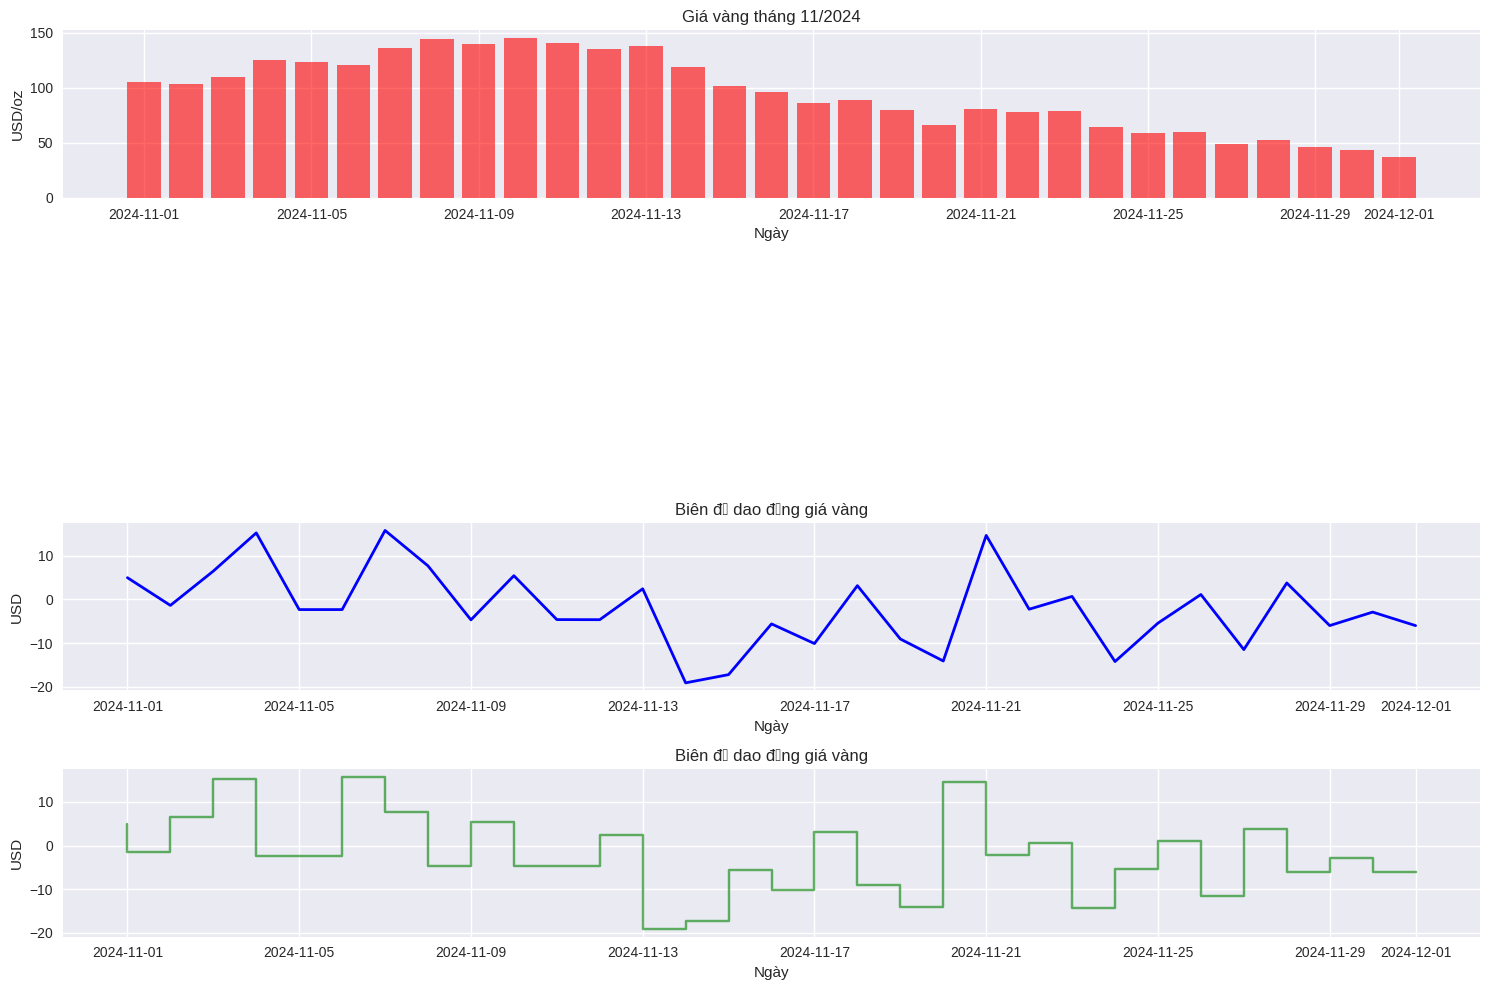

In [70]:
# @title Sau khi có dữ liệu thì bắt đầu dùng chart để biểu thị {"vertical-output":true}
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
''' Đọc file excel (bước này cho sát thực tế) kèm các option khi đọc file '''
df = pd.read_excel('gia_vang_11_2024.xlsx',
                   #sheet_name='Sheet1', (mặc định là sheet 1)
                   header=0,
                   index_col=None,
                   usecols=None,     # Chỉ định cột nhập vào bảng tính
                   engine='openpyxl',      # Engine đọc file excel openpy để đọc file xlsx
                   skiprows=None,           #Số dòng row bỏ qua
                   nrows=None,              #số dòng row muốn đọc, kết hợp skiprows, vd: nrows=200, skiprows=100 thì sẽ đọc từ row 101 -> 200
                                      )
                    # Tạm đủ dùng mấy tham số khác ít dùng thường + e chưa hiểu

'''# Thiết lập kiểu cho matplotlib - công cụ vẽ chart'''
''' kiểu seaborn đang đc giới làm data chuộng, sở trường e là môn ăn chơi nhảy múa với AI phía dưới '''
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(15, 10))
# Subplot 1: Giá vàng theo thời gian
plt.subplot(4, 1, 1)
plt.bar(df['Ngày'], df['Giá USD']-2000, color='r', alpha=0.6)
plt.title('Giá vàng tháng 11/2024')
plt.xlabel('Ngày')
plt.ylabel('USD/oz')
plt.grid(True)


# Subplot 2: Biên độ dao động với dạng plot
plt.subplot(4, 1, 3)
plt.plot(df['Ngày'], df['Biến động'], 'b-', linewidth=2)
plt.title('Biên độ dao động giá vàng')
plt.xlabel('Ngày')
plt.ylabel('USD')
plt.grid(True)

# Subplot 2: Biên độ dao động với dạng step
plt.subplot(4, 1, 4)
plt.step(df['Ngày'], df['Biến động'], color='g', alpha=0.6)
plt.title('Biên độ dao động giá vàng')
plt.xlabel('Ngày')
plt.ylabel('USD')
plt.grid(True)

# Điều chỉnh layout
plt.tight_layout()

# In một số thống kê
print("Thống kê:")
print(f"Giá trung bình: {df['Giá USD'].mean():.2f} USD/oz")
print(f"Giá cao nhất: {df['Giá USD'].max():.2f} USD/oz")
print(f"Giá thấp nhất: {df['Giá USD'].min():.2f} USD/oz")
print(f"Độ biến động trung bình: {df['Biến động'].abs().mean():.2f} USD")
print(f"Độ biến động lớn nhất: {df['Biến động'].abs().max():.2f} USD")

## Nhìn code có vẻ hơi đáng sợ. Nhưng nếu kếu hợp với AI (Theo quan điểm cá nhân thì Claude - 3.5 Sonnet cho kết quả tốt hơn, gần đây ChatGPT hay trả lời chế cháo lắm) chỉ cần đưa điều kiện dùng ngôn ngữ Python trong môi trường Google Colab là có kết quả. Do python giống mẹ bọn AI bây giờ, nên này là tiếng mẹ đẻ AI mà

